<a href="https://colab.research.google.com/github/Tuhin092005/Project_4_Fuel_Efficiency_Prediction_Using_Machine_Learning/blob/main/Fuel_Efficiency_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# Load dataset

df = pd.read_csv("auto-mpg.csv")

In [3]:
# Preview / Display the dataset

df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [4]:
# Check number of rows and columns

df.shape

(398, 9)

In [5]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [6]:
# Display statistical summary

df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [7]:
# Replace '?' with NaN

df['horsepower'] = df['horsepower'].replace('?', np.nan)

In [8]:
# Convert horsepower to numeric

df['horsepower'] = pd.to_numeric(df['horsepower'])

In [9]:
# Fill missing values

df.isnull().sum()

df.fillna(df.mean(numeric_only=True), inplace=True)

In [10]:
# Check and handle duplicate rows

df.duplicated().sum()

df.drop_duplicates(inplace=True)

In [11]:
# Separate features and target

X = df.drop(['mpg', 'car name'], axis=1)

y = df['mpg']

In [12]:
# Encode categorical data

categorical_columns = X.select_dtypes(include='object').columns

encoder = LabelEncoder()

for column in categorical_columns:
    X[column] = encoder.fit_transform(X[column])

In [13]:
# Feature scaling

feature_names = X.columns

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [14]:
# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
# Train Linear Regression model

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [16]:
# Model evaluation for Linear Regression

mae_lr = mean_absolute_error(y_test, y_pred_lr)

mse_lr = mean_squared_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(mse_lr)

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance")
print("-----------------------------")
print("MAE :", round(mae_lr, 2))
print("MSE :", round(mse_lr, 2))
print("RMSE:", round(rmse_lr, 2))
print("R² Score:", round(r2_lr, 4))

Linear Regression Performance
-----------------------------
MAE : 2.25
MSE : 8.2
RMSE: 2.86
R² Score: 0.8476


In [17]:
# Train Decision Tree Regression model

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [18]:
# Model evaluation for Decision Tree

mae_dt = mean_absolute_error(y_test, y_pred_dt)

mse_dt = mean_squared_error(y_test, y_pred_dt)

rmse_dt = np.sqrt(mse_dt)

r2_dt = r2_score(y_test, y_pred_dt)


print("Decision Tree Regression Performance")
print("------------------------------------")
print("MAE :", round(mae_dt, 2))
print("MSE :", round(mse_dt, 2))
print("RMSE:", round(rmse_dt, 2))
print("R² Score:", round(r2_dt, 4))

Decision Tree Regression Performance
------------------------------------
MAE : 2.21
MSE : 11.15
RMSE: 3.34
R² Score: 0.7926


In [19]:
# Train Random Forest Regression model

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [20]:
# Model evaluation for Random Forest

mae_rf = mean_absolute_error(y_test, y_pred_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(y_test, y_pred_rf)


print("Random Forest Regression Performance")
print("------------------------------------")
print("MAE :", round(mae_rf, 2))
print("MSE :", round(mse_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R² Score:", round(r2_rf, 4))

Random Forest Regression Performance
------------------------------------
MAE : 1.59
MSE : 4.61
RMSE: 2.15
R² Score: 0.9143


In [21]:
# Compare all models

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regression",
        "Random Forest Regression"
    ],

    "R² Score": [
        r2_lr,
        r2_dt,
        r2_rf
    ]
})

model_comparison

,Model,R² Score
0,Linear Regression,0.847573
1,Decision Tree Regression,0.792580
2,Random Forest Regression,0.914278


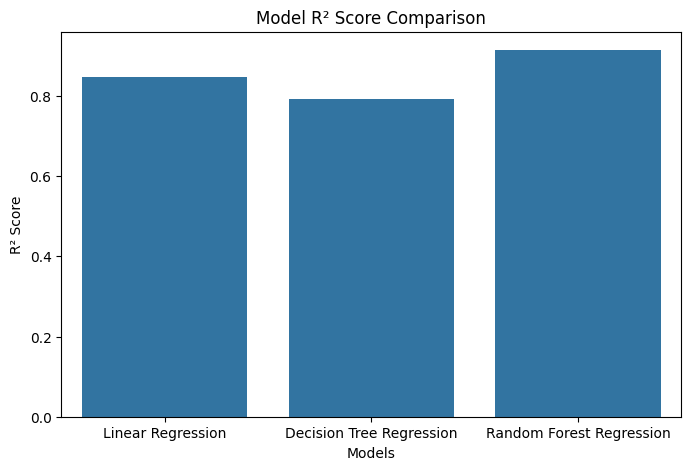

In [22]:
# Plot R² score graph

plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="R² Score",
    data=model_comparison
)

plt.title("Model R² Score Comparison")
plt.xlabel("Models")
plt.ylabel("R² Score")

plt.show()

In [23]:
# Find the best model

best_model = model_comparison.loc[
    model_comparison["R² Score"].idxmax()
]

print(best_model)

Model       Random Forest Regression
R² Score                    0.914278
Name: 2, dtype: object


In [24]:
# Selecting Random Forest as the final model

final_model = rf

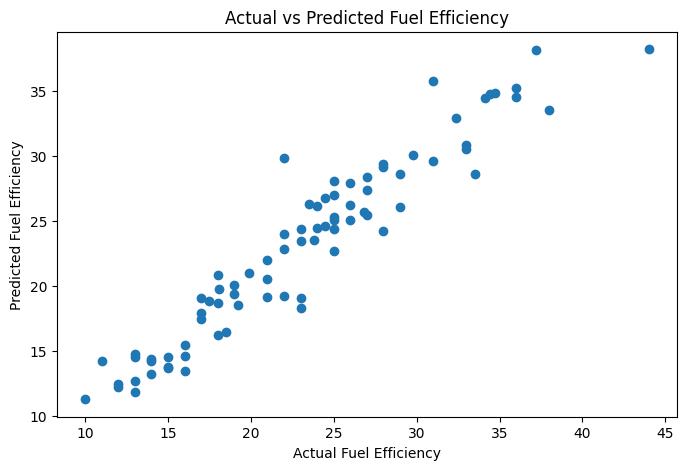

In [25]:
# Plot actual vs predicted values

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred_rf
)

plt.xlabel("Actual Fuel Efficiency")
plt.ylabel("Predicted Fuel Efficiency")

plt.title("Actual vs Predicted Fuel Efficiency")

plt.show()

In [26]:
# Calculate feature importance

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": final_model.feature_importances_
})

In [27]:
# Sort feature importance

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,displacement,0.444208
3,weight,0.149646
0,cylinders,0.129923
2,horsepower,0.126582
5,model year,0.115220
4,acceleration,0.028410
6,origin,0.006012


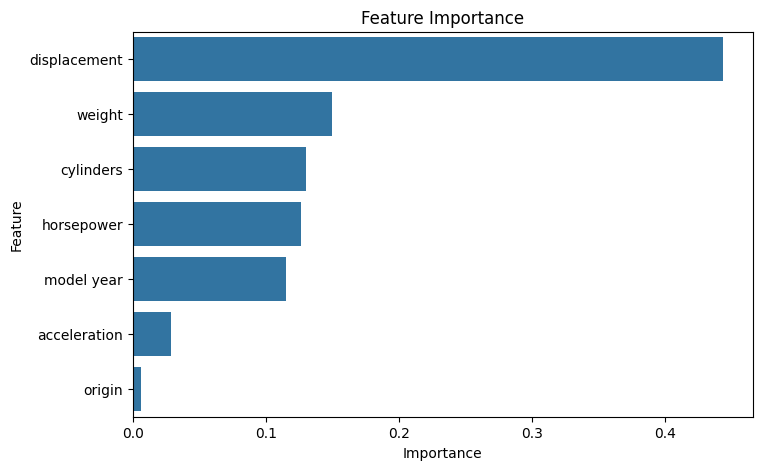

In [28]:
# Plot feature importance

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

In [29]:
# Create new data

new_data = pd.DataFrame({
    'cylinders': [4],
    'displacement': [140.0],
    'horsepower': [90.0],
    'weight': [2400],
    'acceleration': [15.5],
    'model year': [82],
    'origin': [1]
})

In [30]:
# Encode categorical features

for column in categorical_columns:
    new_data[column] = encoder.fit_transform(new_data[column])

In [31]:
# Apply feature scaling to the new data

new_data = scaler.transform(new_data)

In [32]:
# Predict fuel efficiency

prediction = final_model.predict(new_data)

In [33]:
# Display the predicted fuel efficiency

print("Predicted Fuel Efficiency:", prediction[0], "km/L")

Predicted Fuel Efficiency: 31.086 km/L
